In [7]:
# --- Step 0: Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# --- Step 1: Load raw data ---
df = pd.read_csv("../data/raw.csv")
print("Initial shape:", df.shape)
df.head()

Initial shape: (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [9]:
# --- Step 2: Quick overview ---
print("Columns:", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Optional: basic stats
df.describe()

Columns: Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='str')

Missing values:
 Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Duplicates: 0


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


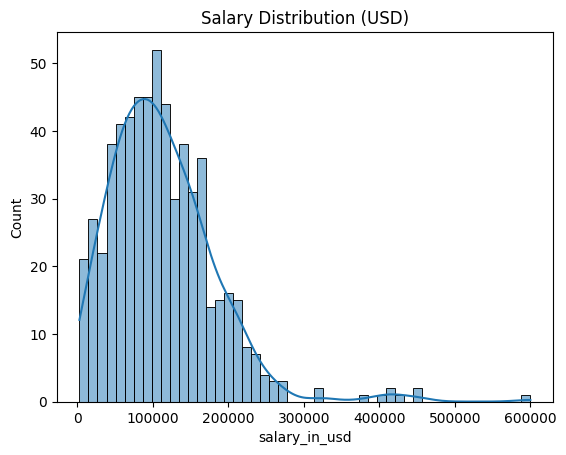

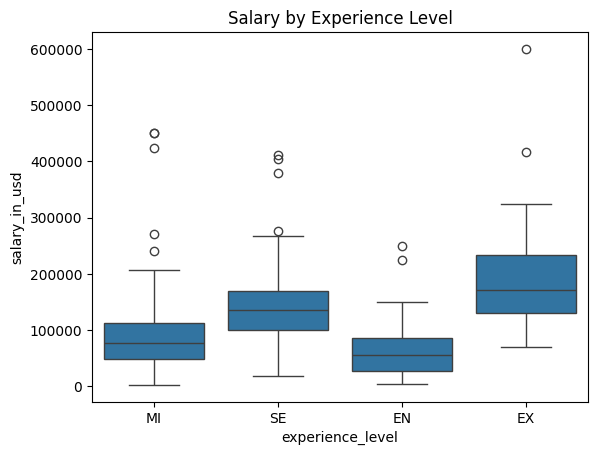

In [10]:
# --- Step 3: Visual exploration ---

# Target distribution
sns.histplot(df['salary_in_usd'], kde=True, bins=50)
plt.title("Salary Distribution (USD)")
plt.show()

# Example: experience level vs salary
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title("Salary by Experience Level")
plt.show()

In [11]:
# --- Step 4: Categorical features overview ---
categorical_cols = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))  # show top 10 only


--- experience_level ---
experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64

--- employment_type ---
employment_type
FT    588
PT     10
CT      5
FL      4
Name: count, dtype: int64

--- job_title ---
job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
Name: count, dtype: int64

--- employee_residence ---
employee_residence
US    332
GB     44
IN     30
CA     29
DE     25
FR     18
ES     15
GR     13
JP      7
PK      6
Name: count, dtype: int64

--- company_location ---
company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
NL      4
Name: count, dtype: int64

--- company_size ---
company_size
M    326
L  

In [12]:
# --- Step 5: Data Cleaning (connect Step 1) ---

# Drop unnecessary columns
df = df.drop(columns=["salary", "salary_currency"])  # we only use salary_in_usd

# Handle missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Save cleaned dataset
df.to_csv("../data/cleaned.csv", index=False)
print("Cleaned shape:", df.shape)
print("Cleaned dataset saved to data/cleaned.csv ✔")

Cleaned shape: (607, 10)
Cleaned dataset saved to data/cleaned.csv ✔
